In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## data cleaning

In [2]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1)
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [4]:
df.isna().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [5]:
df[df.isna().any(axis= 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


Sinc we have two region here we will sepearte aur dataset on based on labelling like 0 for one and 1 for other
0 for "Bejaia Region Dataset"
1 for "Sidi-Bel Abbes Region Dataset"

In [6]:
df.loc[:122,"Region"] = 0
df.loc[122:,"Region"] = 1

In [7]:
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0


In [8]:
df["Region"] = df['Region'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       246 non-null    int32 
dtypes: int32(1), object(14)
memory usage: 28.0+ KB


In [9]:
df[df.isna().any(axis= 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,1


In [10]:
df.drop(index=122).reset_index()

,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1
241,242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1
242,243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
243,244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


In [11]:
df.dropna(inplace=True)

In [12]:
df = df.reset_index(drop=True)

In [13]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [14]:
df.drop(index=122,inplace=True)


In [15]:
df.reset_index(drop = True,inplace=True)

In [16]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [17]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [18]:
df.columns = df.columns.str.strip(" ")
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [19]:
df_num = [col for col in df.columns if col != "Classes"]
df_num

['day',
 'month',
 'year',
 'Temperature',
 'RH',
 'Ws',
 'Rain',
 'FFMC',
 'DMC',
 'DC',
 'ISI',
 'BUI',
 'FWI',
 'Region']

In [20]:
for i in df_num:
    df[i] = df[i].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    float64
 1   month        243 non-null    float64
 2   year         243 non-null    float64
 3   Temperature  243 non-null    float64
 4   RH           243 non-null    float64
 5   Ws           243 non-null    float64
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(14), object(1)
memory usage: 28.6+ KB


In [21]:
df["Classes"]=  df["Classes"].str.strip(" ")
df["Classes"].unique()

array(['not fire', 'fire'], dtype=object)

In [22]:
## save the cleaned dataset
df.to_csv("ceaned forest dataset",index=False)

## EDA

In [23]:
df_ = df.drop(["day","month","year"],axis=1)
df_.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0


In [24]:
## Encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[["Classes"]]).toarray()
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
df_ = pd.concat([df_,encoded_df],axis=1)
df_.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region,Classes_fire,Classes_not fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0,0.0,1.0


In [25]:
df_ = df_.drop("Classes",axis=1)
df_.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Classes_fire,Classes_not fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0.0,0.0,1.0


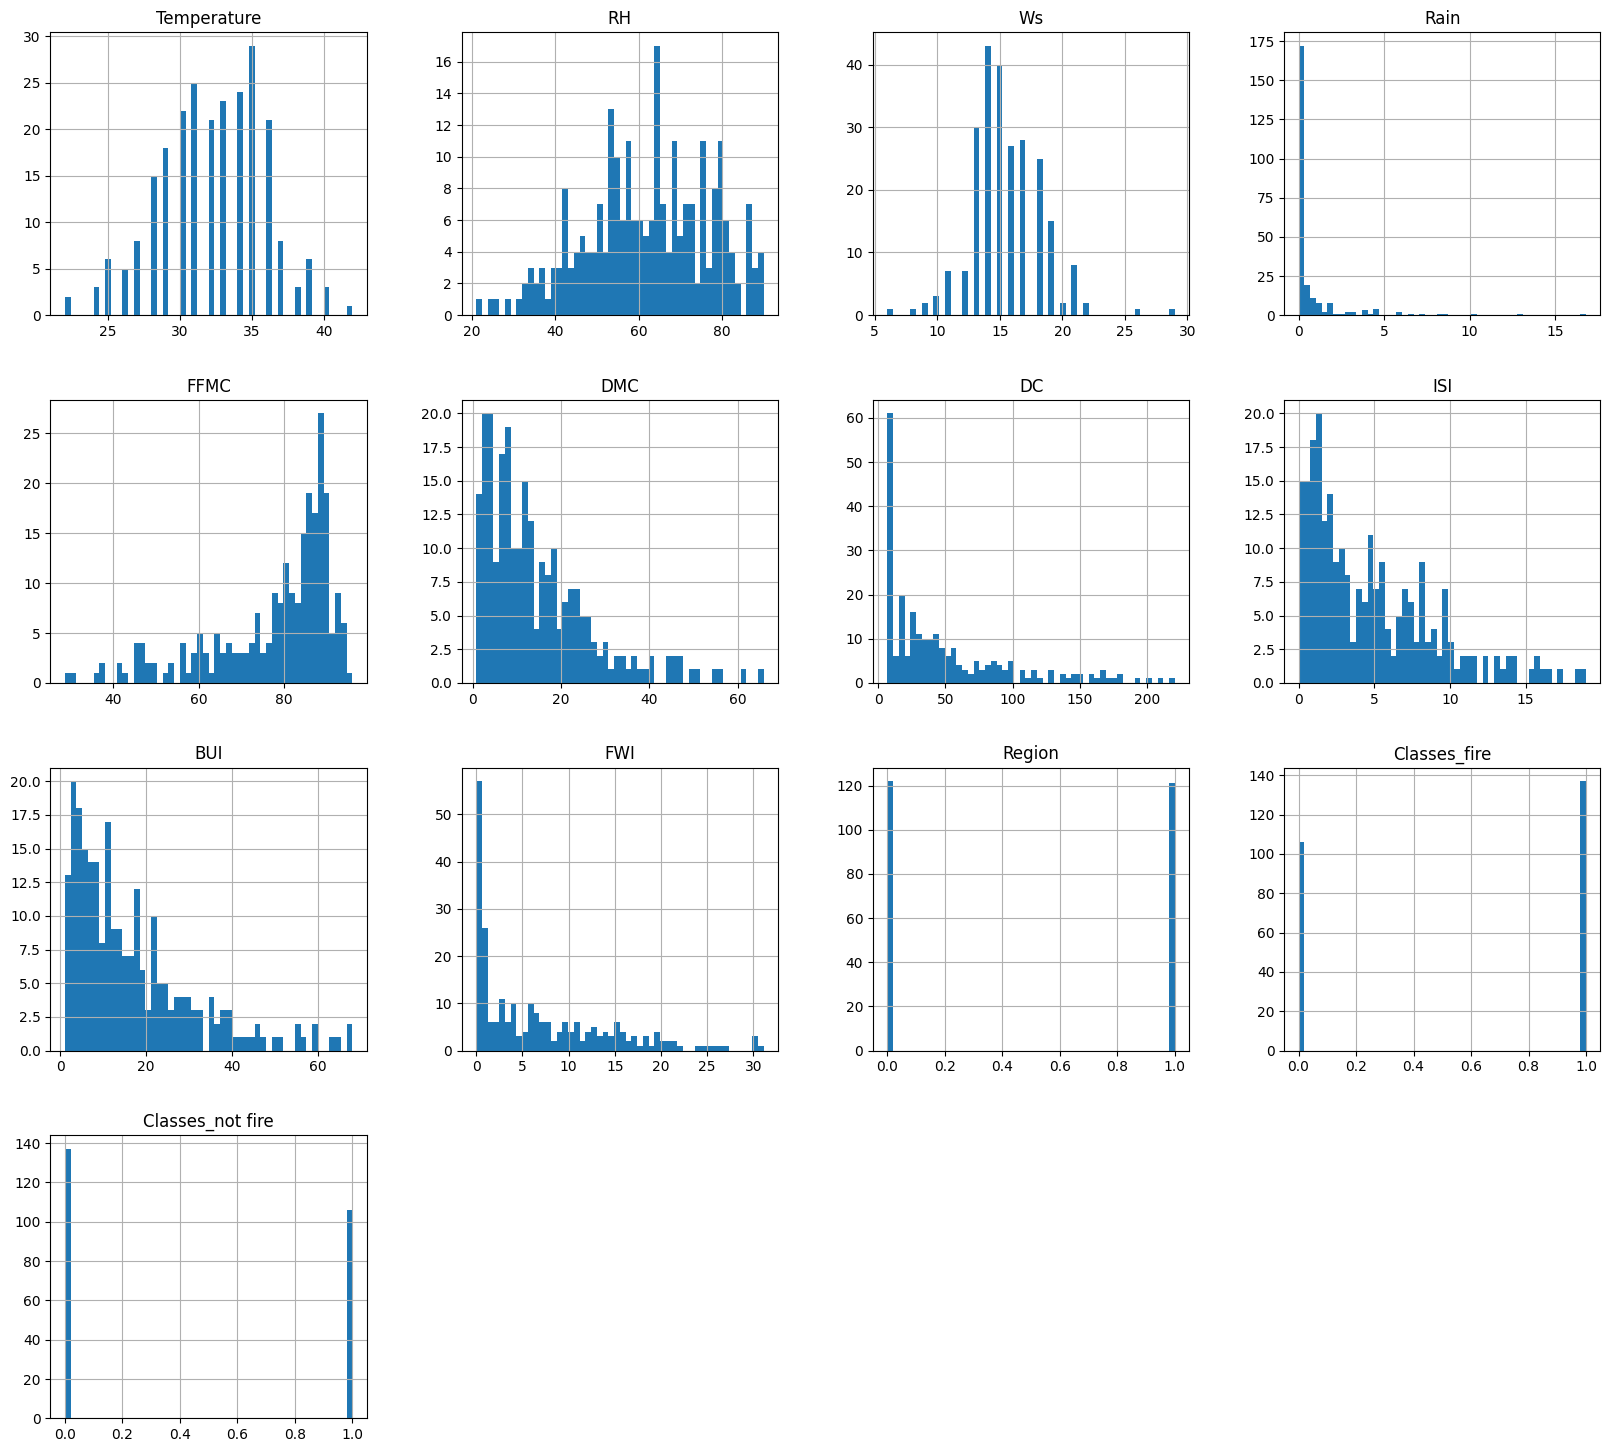

In [26]:
## density plot
df_.hist(bins=  50,figsize=(20,18))
plt.show()

<Axes: >

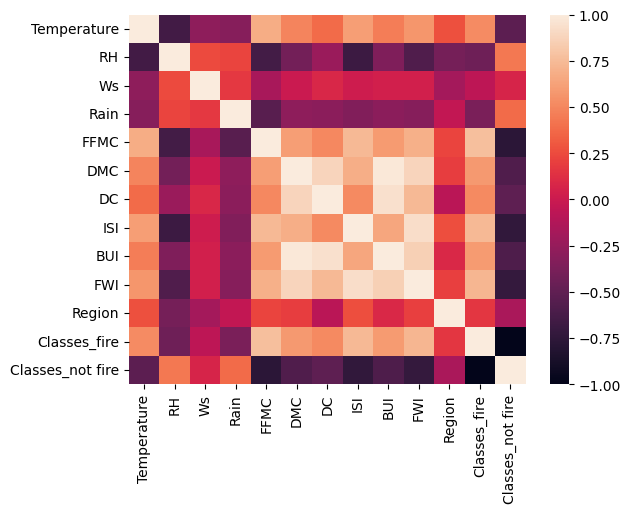

In [27]:

df_.corr()
sns.heatmap(df_.corr())

<Axes: xlabel='month', ylabel='count'>

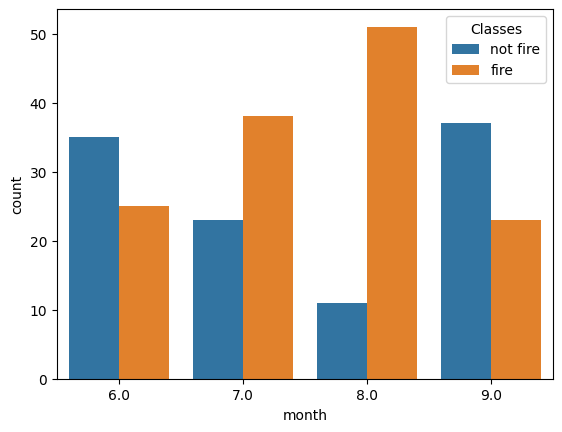

In [28]:
sns.countplot(x="month",hue="Classes",data=df)


## 

In [29]:
df_.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Classes_fire,Classes_not fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0.0,0.0,1.0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0.0,0.0,1.0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0.0,0.0,1.0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0.0,0.0,1.0


In [30]:
df1 = df_.copy()

In [31]:
df1.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Classes_fire,Classes_not fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0.0,0.0,1.0


In [32]:
X = df1.drop("FWI",axis=1)
X.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Region,Classes_fire,Classes_not fire
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.0,0.0,1.0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.0,0.0,1.0


In [33]:
y = df1[["FWI"]]
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


In [34]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=.25,random_state=42)


In [35]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Region,Classes_fire,Classes_not fire
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.254549,0.542141,-0.542141
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.394665,-0.456876,0.456876
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.199969,-0.082570,0.082570
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.059022,-0.369357,0.369357
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.249514,0.781259,-0.781259
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.212582,0.617273,-0.617273
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,-0.060838,0.543581,-0.543581
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.296441,0.742977,-0.742977
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.114897,0.612239,-0.612239
Region,0.254549,-0.394665,-0.199969,-0.059022,0.249514,0.212582,-0.060838,0.296441,0.114897,1.000000,0.188837,-0.188837


<Axes: >

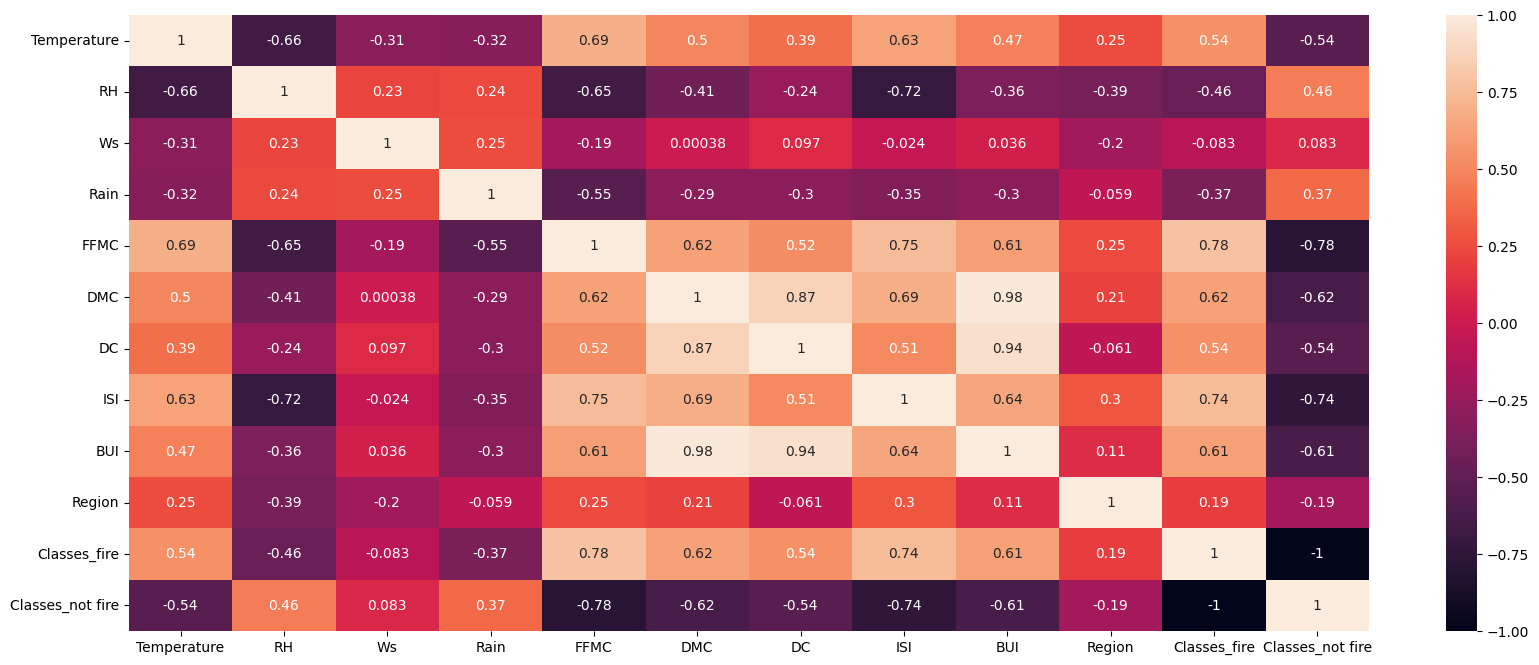

In [36]:
plt.figure(figsize=(20,8))
sns.heatmap(X_train.corr(),annot=True)

In [37]:
def corr_check(dataset,threshold):
    col_corr = set()
    corr_val = dataset.corr()
    for i in range(len(corr_val.columns)):
        for j in range(i):
            if abs(corr_val.iloc[i,j])>threshold:
                name = corr_val.columns[i]
                col_corr.add(name)
    return col_corr
corr_featuers = corr_check(X_train,.85)
print(corr_featuers)


{'DC', 'Classes_not fire', 'BUI'}


In [38]:
corr_featuers.remove("Classes_not fire")
print(corr_featuers)

{'DC', 'BUI'}


In [39]:
X_train.drop(corr_featuers,axis=1,inplace=True)
X_test.drop(corr_featuers,axis=1,inplace=True)

In [40]:
X_test.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Region,Classes_fire,Classes_not fire
24,31.0,64.0,15.0,0.0,86.7,14.2,5.7,0.0,1.0,0.0
6,33.0,54.0,13.0,0.0,88.2,9.9,6.4,0.0,1.0,0.0


In [41]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)


<Axes: >

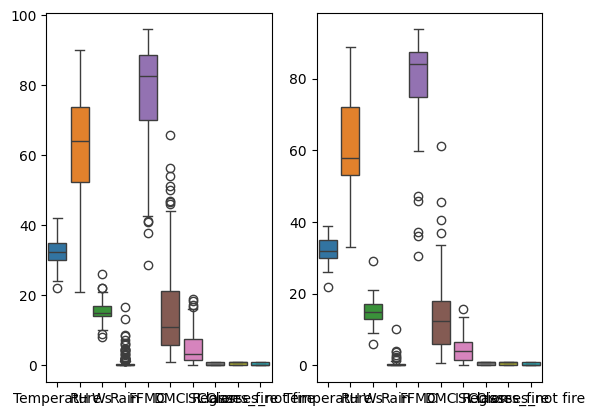

In [42]:
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.subplot(1,2,2)
sns.boxplot(data=X_test)

## Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg = LinearRegression()
linreg.fit(X_train_Scaled,y_train)
y_pred = linreg.predict(X_test_Scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MAE",mae)
print("R2",r2)

MAE 0.5468236465249984
R2 0.9847657384266951


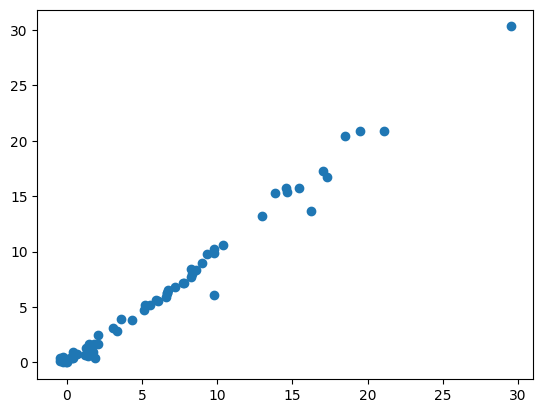

In [44]:
plt.scatter(y_pred,y_test)

In [45]:
## Lasso reg
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
las = Lasso()
las.fit(X_train_Scaled,y_train)
y_pred = las.predict(X_test_Scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MAE",mae)
print("R2",r2)

MAE 1.133175994914409
R2 0.9492020263112388


In [46]:
## Ridge reg
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge = Ridge()
ridge.fit(X_train_Scaled,y_train)
y_pred = ridge.predict(X_test_Scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MAE",mae)
print("R2",r2)

MAE 0.5642932965866448
R2 0.9843025984563801


In [47]:
## elactice reg
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
e_Net = ElasticNet()
e_Net.fit(X_train_Scaled,y_train)
y_pred = e_Net.predict(X_test_Scaled)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MAE",mae)
print("R2",r2)

MAE 1.8843260303250795
R2 0.8741465614131025


## hyperparameter tunning

In [48]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV()
lassocv.fit(X_train_Scaled,y_train)


C:\Users\Abhishek Goswami\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LassoCV()

In [49]:
y_pred = lassocv.predict(X_test_Scaled)
y_pred

array([ 8.17497542,  7.68321641, -0.25684957,  4.72625911,  6.78706509,
        1.7760892 ,  2.23140682,  7.64048378,  1.99175715,  3.3994072 ,
        0.62807882,  9.95922936,  9.3616326 , 16.98499438, 18.28499041,
        1.61630273,  1.62740001, -0.64142671,  7.28516771,  3.1091686 ,
        1.95543005,  0.18075263,  6.4757303 ,  0.14325111, 20.99608382,
        5.11746658,  5.86213241,  9.75920329, -0.77020324,  9.91837074,
        6.72282654, -0.31786163, 10.31117868, 14.43659799,  1.71023425,
        0.83426188,  2.03420664,  5.97477311, -0.62640512, -0.56203051,
        6.47257439,  2.07970832,  8.46746678, -0.84630695, 15.40444771,
        8.32947385,  8.48772588,  1.44032618, 13.027485  ,  1.2091464 ,
       29.08618961,  5.49728503, 17.1594592 , 19.28896369, 13.71118111,
       16.05351638,  0.99043089,  9.08732323,  3.84447788, 14.43987457,
        5.2302743 ])

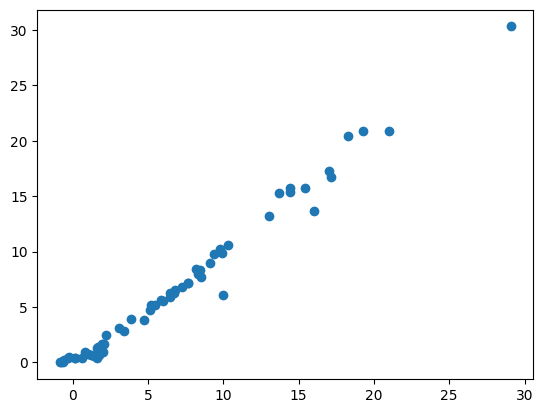

In [50]:
plt.scatter(y_pred,y_test)

In [51]:
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MAE",mae)
print("R2",r2)

MAE 0.6199476950828846
R2 0.9820962755368671


Pickle the ML models,preprocessing model standard scaler

In [52]:
scaler

StandardScaler()

In [53]:
ridge

Ridge()

## Model Pickling

In [54]:
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))
pickle.dump(ridge,open("ridge.pkl","wb"))  